## Tarea. Clasificación de variables

Elaborar una tabla donde se clasifique cada variable del dataset en una de las siguientes categorías:

- identificador,
- numérica,
- categórica nominal,
- ordinal,
- variable objetivo binaria.

### Entregable

Entregar un notebook que incluya:

- tablas,
- gráficas,
- interpretaciones breves,
- y una conclusión final de media a una cuartilla donde se resuma:

  - qué se observó en las variables `PAY_*`,
  - qué tipo de correlación sería más adecuado según el tipo de variable,
  - y por qué es importante distinguir entre variables numéricas, categóricas y ordinales antes de modelar.

## Solución de la Tarea

Primero importamos las librerías necesarias.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Importamos los datos

In [2]:
f = "../data/default of credit card clients.xls" # cambialo por la ruta de tu archivo

df = pd.read_excel(f, header=1) # el header=1 indica que la primera fila es el encabezado
df # muestra las primeras filas del dataframe

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [3]:
# Renombrado de columnas
df = df.rename(columns={
    "default payment next month": "default_next_month",
    "PAY_0": "PAY_1"
})
df # muestra las primeras filas del dataframe con las columnas renombradas

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


Se elaboro una tabla donde se clasifica cada variable del dataset en una de las siguientes categorías:

- identificador,
- numérica,
- categórica nominal,
- ordinal,
- variable objetivo binaria.

In [4]:
# Resumen de tipos de variables
variable_types = pd.DataFrame({
    "variable": [
        "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
        "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
        "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
        "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
        "default_next_month"
    ],
    "tipo_sugerido": [
        "Identificador", "Numérica", "Categórica nominal", "Categórica",
        "Categórica nominal", "Numérica",
        "Ordinal", "Ordinal", "Ordinal", "Ordinal", "Ordinal", "Ordinal",
        "Numérica", "Numérica", "Numérica", "Numérica", "Numérica", "Numérica",
        "Numérica", "Numérica", "Numérica", "Numérica", "Numérica", "Numérica",
        "Objetivo binaria"
    ]
})

variable_types

,variable,tipo_sugerido
0,ID,Identificador
1,LIMIT_BAL,Numérica
2,SEX,Categórica nominal
3,EDUCATION,Categórica
4,MARRIAGE,Categórica nominal
5,AGE,Numérica
6,PAY_1,Ordinal
7,PAY_2,Ordinal
8,PAY_3,Ordinal
9,PAY_4,Ordinal


### Análisis del historial de pago (Variables de PAY_*)

**Interpretación breve:** En las siguientes gráficas evaluamos la tasa de incumplimiento cruzada con los meses de retraso (`PAY_1` a `PAY_6`). Se puede observar que los clientes que pagan a tiempo (valores de 0 o -1) tienen una probabilidad sumamente baja de incumplimiento. Sin embargo, a medida que el cliente acumula meses de atraso (valores de 1, 2, 3...), el riesgo de incumplimiento al mes siguiente crece drásticamente.

### Nota Técnica: Interpretación de Categorías No Documentadas en Variables `PAY_*`

Durante la exploración de la base de datos, se detectó que la documentación original del dataset omite el significado de los valores numéricos `-2` y `0` en las variables del historial de pagos (`PAY_0` a `PAY_6`). Tras analizar el comportamiento de la información, se establece la siguiente interpretación técnica:

* **`-2` (Sin consumo / Saldo en ceros):** La cuenta no tuvo actividad de cobro en ese mes. El cliente no usó la tarjeta y no tenía deuda pendiente.
* **`-1` (Pago total / "Pay duly"):** El cliente utilizó la tarjeta y liquidó el 100% de su estado de cuenta a tiempo (cliente "totalero").
* **`0` (Crédito revolvente / Pago mínimo):** El cliente tenía deuda y no la liquidó por completo, pero realizó al menos el pago mínimo a tiempo. El cliente está al corriente, pero "revolviendo" deuda y generando intereses.
* **`1, 2, 3...` (Meses de atraso):** El cliente no cubrió ni siquiera el pago mínimo exigido durante esa cantidad de meses.

**Justificación de esta interpretación:**
La validación empírica de esta teoría se encuentra en nuestras propias gráficas de la *Tasa de Incumplimiento*. Al visualizar los datos, las categorías `-2`, `-1` y `0` presentan proporciones de incumplimiento futuro sumamente bajas y muy similares entre sí. Esto demuestra que estadísticamente las tres representan a clientes con un historial crediticio "sano" en ese mes. El verdadero salto en el riesgo estadístico ocurre a partir de la categoría `1`, marcando la frontera real donde comienza el impago. Por lo tanto, estos valores no son errores de captura, sino estados financieros válidos que deben conservarse para el modelado.

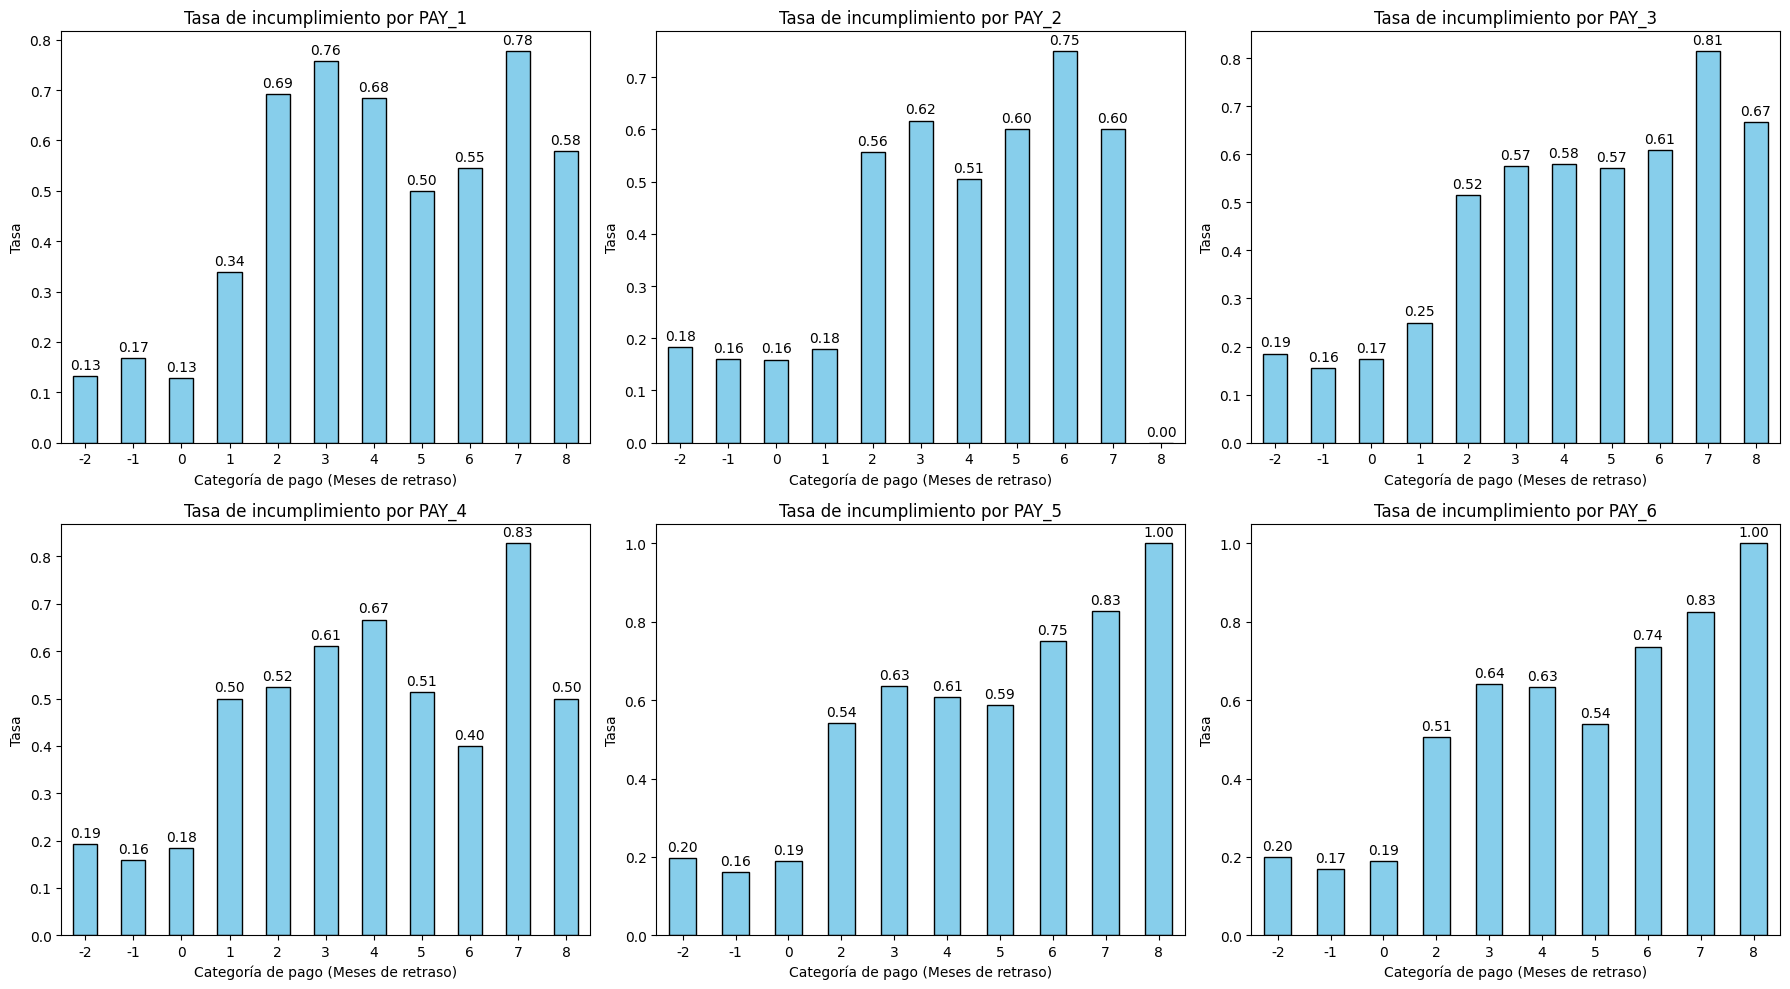

In [5]:
variables_pago = [f"PAY_{i}" for i in range(1, 7)]

# Creamos el apnel de graficos
fig, ax = plt.subplots(2,3,figsize=(18, 10)) # 2 filas, 3 columnas
ax = ax.flatten() # aplanamos el array de ejes para iterar fácilmente

for i, var in enumerate(variables_pago):
    # Calculamos la tasa de incumplimiento para cada categoria de la variable de pago
    tasa_incumplimiento = df.groupby(var)["default_next_month"].mean()
    # Graficamos la tasa de incumplimiento
    tasa_incumplimiento.plot(kind="bar", color="skyblue", edgecolor="black", ax=ax[i])

    ax[i].bar_label(ax[i].containers[0], fmt='%.2f', padding=3)
    ax[i].set_title(f'Tasa de incumplimiento por {var}')
    ax[i].set_xlabel('Categoría de pago (Meses de retraso)')
    ax[i].set_ylabel('Tasa')
    ax[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


Antes de definir cual es la mejor correlación según nuestros datos, primero expliquemos que es cada cosa.

### Fundamentos Estadísticos: Análisis de Correlación

En el análisis exploratorio de datos, la **correlación** es una métrica estadística fundamental que cuantifica el grado de asociación o dependencia entre dos variables. Su objetivo principal es determinar tanto la dirección (positiva o negativa) como la magnitud de la relación matemática entre las variables de estudio. 

Existen distintas metodologías para calcular esta métrica, siendo las más utilizadas en la ciencia de datos los coeficientes de **Pearson** y **Spearman**, cuya elección depende estrictamente de la naturaleza y distribución de los datos.

### Coeficiente de Correlación de Pearson (Relación Lineal)

La correlación de Pearson es el método tradicional que evalúa la **relación lineal** perfecta entre dos variables continuas. Matemáticamente, este método intenta ajustar una línea recta a través de la dispersión de los datos.

**Supuestos analíticos:** Asume que los datos siguen una distribución normal (distribución gaussiana) y que el cambio entre las variables ocurre a un ritmo constante y proporcional.

**Limitación principal (Sensibilidad a Outliers):** Este coeficiente utiliza los valores numéricos absolutos exactos. Por lo tanto, es **extremadamente sensible a los valores atípicos**. Un solo valor extremo (por ejemplo, una deuda multimillonaria en una base de datos) puede distorsionar drásticamente la línea matemática, sugiriendo relaciones lineales que son falsas o engañosas.

### Coeficiente de Correlación de Spearman (Relación Monotónica)

La correlación de Spearman es un método no paramétrico que evalúa la **relación monotónica** entre dos variables. Una relación monotónica indica que cuando una variable aumenta, la otra también lo hace (o disminuye), pero no asume que lo hagan formando una línea recta perfecta.

**Metodología por Rangos:** A diferencia de Pearson, Spearman no opera con los valores numéricos absolutos, sino que transforma los datos evaluando su jerarquía o posición relativa (**ranking**). El valor más bajo recibe el rango 1, el siguiente el rango 2, y así sucesivamente.

**Ventajas principales:**
 1. **Robustez ante valores atípicos:** Al convertir magnitudes extremas simplemente en el "primer lugar" del ranking, el coeficiente diluye y neutraliza el sesgo matemático que los *outliers* le causarían al método de Pearson.
 2. **Aplicabilidad categórica:** Es el método matemático idóneo para medir la asociación en **variables ordinales** (variables categóricas con un orden lógico inherente, como los "meses de atraso" en un historial de pagos).

### Metodología para la Selección del Coeficiente de Correlación

En ciencia de datos, la directriz metodológica estándar para el análisis de correlación es la siguiente: **asumir el uso de Spearman por defecto, a menos que se demuestre estadísticamente que es válido utilizar Pearson.**

El coeficiente de Pearson es altamente paramétrico y restrictivo. Para justificar su uso, los datos deben cumplir estrictamente con una serie de supuestos estadísticos. Si uno solo de estos supuestos es violado, la alternativa más robusta y matemáticamente correcta es el coeficiente de Spearman. 

A continuación, se detallan las pruebas visuales y estadísticas necesarias para tomar esta decisión:

### 1. Evaluación de Normalidad (Distribución de los Datos)
Pearson exige que las variables numéricas analizadas sigan una distribución normal (distribución gaussiana o forma de campana simétrica).

* **Prueba Visual (Histograma o Gráfico Q-Q):** Permite evaluar visualmente la simetría de los datos. Si la distribución presenta un sesgo pronunciado hacia la derecha o izquierda (común en variables financieras, donde la concentración está en valores bajos y se extiende hacia valores extremos), el supuesto de normalidad se viola.
* **Prueba Estadística (Shapiro-Wilk o D'Agostino-Pearson):** Para conjuntos de datos grandes, pruebas como D'Agostino-Pearson calculan un valor *p* (*p-value*). Si el *p-value* es menor al nivel de significancia (usualmente 0.05), se rechaza la hipótesis nula de que los datos provienen de una distribución normal.
* **Interpretación:** Si no existe normalidad → **Correlación de Spearman**.

### 2. Detección de Valores Atípicos (Outliers)
El coeficiente de Pearson utiliza los valores numéricos absolutos para calcular la varianza, haciéndolo extremadamente sensible a los valores extremos que distorsionan la tendencia general.

* **Prueba Visual (Diagrama de Caja o Boxplot):** Esta herramienta muestra la dispersión de los datos a través de cuartiles. Si se observan múltiples puntos individuales proyectados más allá de límites superior e inferior, el conjunto presenta valores atípicos severos.
* **Interpretación:** Si existen valores atípicos significativos → **Correlación de Spearman**.

### 3. Evaluación de Linealidad
Pearson está diseñado exclusivamente para detectar relaciones lineales perfectas (es decir, el cambio proporcional constante entre dos variables).

* **Prueba Visual (Diagrama de Dispersión o Scatter plot):** Al graficar la Variable A contra la Variable B, los datos deben agruparse a lo largo de una línea recta imaginaria. Si los puntos forman una curva, un patrón parabólico o una figura cónica, Pearson subestimará gravemente la relación real.
* **Interpretación:** Si la relación es claramente curva pero mantiene un comportamiento monotónico (siempre asciende o siempre desciende) → **Correlación de Spearman**.

### 4. Naturaleza de las Variables (Niveles de Medición)
Más allá de las pruebas estadísticas, la justificación teórica basada en la naturaleza del dato es fundamental.

* **Evaluación Lógica:** Revisar el diccionario de datos. Si una de las variables en cuestión es de tipo **Ordinal** (es decir, representa categorías que poseen un orden lógico inherente, como "1 mes de retraso", "2 meses de retraso", o posiciones en un ranking), el cálculo de medias y varianzas requerido por Pearson carece de sentido matemático.
* **Interpretación:** Si interviene al menos una variable ordinal → **Correlación de Spearman**.

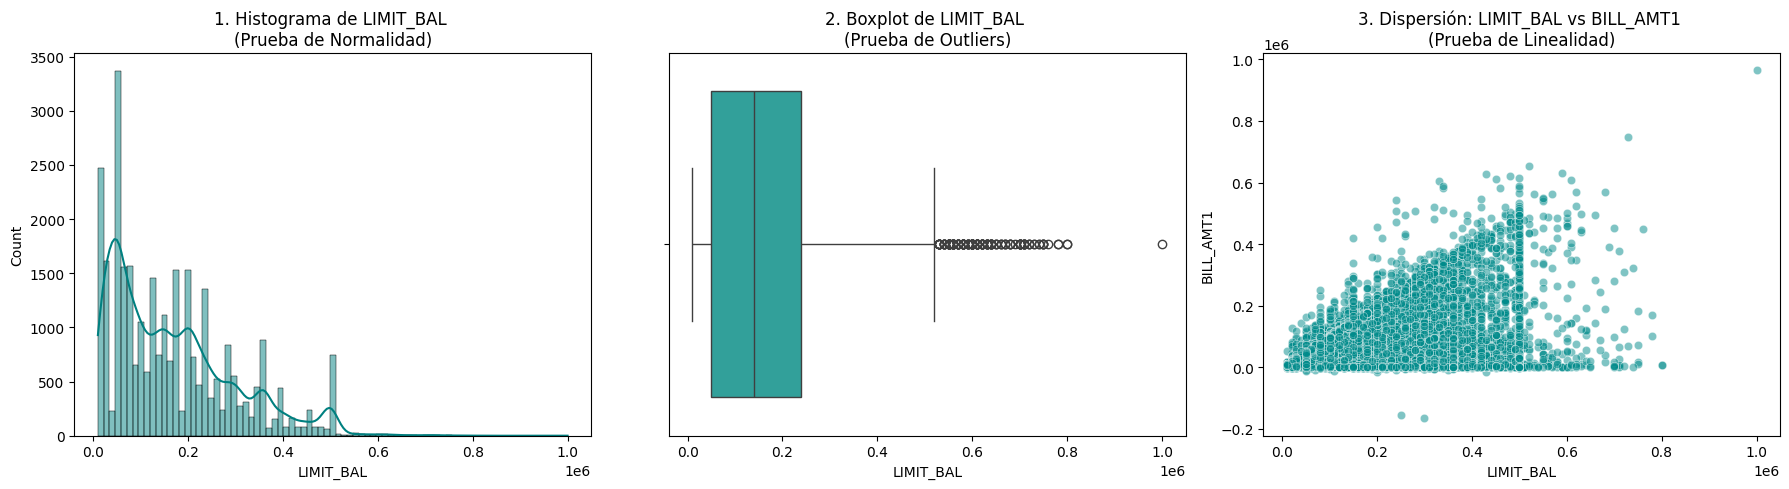

--- Resultados Numéricos ---
Valor p (p-value) de normalidad para LIMIT_BAL: 0.0
Valores únicos encontrados en la variable PAY_1: [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]


In [6]:
f = "../data/default_credit_clean.csv"

df_clean = pd.read_csv(f)

# Variables para las pruebas
var_dinero_1 = 'LIMIT_BAL'
var_dinero_2 = 'BILL_AMT1'
var_ordinal = 'PAY_1'

# Creamos un panel con 3 gráficas (Histograma, Boxplot y Scatterplot)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# PRUEBAS VISUALES
# ---------------------------------------------------------
# 1. Histograma (Prueba de Normalidad Visual)
sns.histplot(x=df_clean[var_dinero_1], kde=True, ax=axes[0], color='teal')
axes[0].set_title(f'1. Histograma de {var_dinero_1} \n(Prueba de Normalidad)')

# 2. Boxplot (Prueba de Valores Atípicos)
sns.boxplot(x=df_clean[var_dinero_1], ax=axes[1], color='lightseagreen')
axes[1].set_title(f'2. Boxplot de {var_dinero_1} \n(Prueba de Outliers)')

# 3. Dispersión (Prueba de Linealidad)
sns.scatterplot(x=df_clean[var_dinero_1], y=df_clean[var_dinero_2], ax=axes[2], color='darkcyan', alpha=0.5)
axes[2].set_title(f'3. Dispersión: {var_dinero_1} vs {var_dinero_2} \n(Prueba de Linealidad)')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# CÁLCULOS ESTADÍSTICOS Y EXTRACCIÓN DE DATOS
# ---------------------------------------------------------
# Prueba Estadística de Normalidad (D'Agostino's K-squared test)
stat, p_value = stats.normaltest(df_clean[var_dinero_1].dropna())

# Extracción de valores únicos (AGREGAMOS .tolist() PARA LIMPIAR LA SALIDA)
categorias = sorted(df_clean[var_ordinal].unique().tolist())

print(f"--- Resultados Numéricos ---")
print(f"Valor p (p-value) de normalidad para {var_dinero_1}: {p_value}")
print(f"Valores únicos encontrados en la variable {var_ordinal}: {categorias}")

### Interpretación de Resultados: Pruebas de Selección de Correlación

Con base en las gráficas generadas y los resultados estadísticos obtenidos, evaluamos la viabilidad de utilizar la correlación de Pearson frente a la de Spearman:

**1 y 2. Evaluación de Normalidad y Valores Atípicos (Outliers)**
* Al analizar el histograma de la variable `LIMIT_BAL`, se observa una distribución fuertemente asimétrica (sesgada hacia la derecha), muy lejana a una distribución normal en forma de campana. 
* Esto se corrobora de forma contundente con la prueba estadística de *D'Agostino's K-squared*, cuyo valor *p* (`p-value`) es prácticamente **0.0** (estrictamente menor al nivel de significancia de 0.05). Por lo tanto, se rechaza la normalidad.
* Adicionalmente, el diagrama de caja (*Boxplot*) evidencia una cantidad masiva de valores atípicos severos en los cuartiles superiores. 
* **Resultado:** Pearson es extremadamente sensible a estas anomalías. El método queda descartado.

**3. Evaluación de Linealidad**
* El diagrama de dispersión (*Scatterplot*) entre `LIMIT_BAL` y `BILL_AMT1` no muestra una tendencia que pueda ajustarse de forma precisa a una línea recta perfecta. En su lugar, se observa una alta concentración (nube de puntos) en los valores bajos, que se va esparciendo de forma irregular a medida que aumentan los montos.
* **Resultado** Al carecer de una relación estrictamente lineal, el supuesto de Pearson vuelve a violarse.

**4. Evaluación de la Naturaleza del Dato**
* Mediante código, extrajimos los valores únicos de la variable del historial de pagos (`PAY_1`), obteniendo el arreglo: `[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]`. 
* Esto comprueba que no se trata de una variable continua, sino de una **variable categórica ordinal** (niveles discretos de meses de atraso). El cálculo matemático de medias y varianzas requerido por Pearson es metodológicamente incorrecto para este tipo de datos.

### Conclusión Metodológica
Debido a la ausencia de distribución normal, la alta presencia de *outliers*, la falta de una relación lineal perfecta y la inclusión de variables de naturaleza ordinal en nuestro conjunto de datos, **el coeficiente de correlación de Pearson queda completamente descartado**. 

Se confirma técnica y estadísticamente que **el coeficiente de Spearman es el método idóneo y robusto** para cuantificar la asociación de variables en este proyecto.

### La Importancia de Clasificar las Variables antes del Modelado

El paso de clasificar las 25 variables del dataset no es un mero formalismo descriptivo, sino el pilar fundamental que dicta la **estrategia de preprocesamiento**. Los algoritmos de *Machine Learning* son funciones matemáticas puras; no tienen "sentido común". Si no clasificamos y transformamos los datos adecuadamente, el modelo extraerá patrones matemáticamente absurdos. La importancia radica en el tratamiento específico que requiere cada tipo de variable:

* **Identificador (`ID`):** Representa solo una etiqueta de fila. Si no la identificamos y la dejamos dentro de los datos de entrenamiento, el algoritmo podría intentar encontrar patrones ridículos (ej. creer que los clientes con un ID par tienen más riesgo). Saber que es un identificador nos obliga a **excluirla** de la matriz de predictores.
* **Variables Categóricas Nominales (`SEX`, `MARRIAGE`):** Representan etiquetas sin ninguna jerarquía. Si las introducimos con su codificación original (ej. 1 = Casado, 2 = Soltero), el algoritmo asumirá erróneamente una relación matemática (creyendo que "Soltero" vale el doble que "Casado"). Clasificarlas nos indica que debemos aplicar técnicas como **One-Hot Encoding** (creación de variables *dummy*) para evitar jerarquías falsas.
* **Variables Ordinales (`PAY_1` a `PAY_6`, `EDUCATION`):** Poseen un orden lógico (ej. más meses de atraso o niveles de estudio), pero la "distancia" entre niveles no es numéricamente exacta. Identificarlas permite decidir el tratamiento adecuado para no asumir linealidad donde solo hay escalones conceptuales.
* **Variables Numéricas Continuas (`LIMIT_BAL`, `AGE`, `BILL_AMT1` a `BILL_AMT6`, `PAY_AMT1` a `PAY_AMT6`):** Tienen una magnitud real. Sin embargo, un límite de crédito o un monto de facturación de $500,000 dominará matemáticamente en la ecuación sobre una edad de 30 años simplemente porque el número es más grande. Agruparlas aquí nos alerta de la necesidad de aplicar técnicas de **Escalado** (Estandarización o Normalización) para que todas las magnitudes compitan en igualdad de condiciones.
* **Variable Objetivo Binaria (`default_next_month`):** Es la variable "Y" que queremos predecir. Identificarla de inmediato y separarla del resto de las variables (nuestra matriz "X") es lo que define la naturaleza de nuestro proyecto: al tener solo dos valores posibles (1 y 0), sabemos de antemano que debemos utilizar algoritmos de **Clasificación** (como Regresión Logística o Bosques Aleatorios) y no de Regresión.

Distinguir la naturaleza estadística de cada variable es lo que nos permite traducir la realidad del negocio al lenguaje matemático puro que requiere el modelo. Omitir este paso garantiza un modelo sesgado, ineficiente y con predicciones lógicamente inválidas.